# The file will try to find the potential correlation between external features and the properties' rental price

### 1. Load the data & doing preprocessing

In [1]:
import pandas as pd
import seaborn as sbs
import matplotlib.pyplot as plt

In [2]:
# load the merged data and delete the features not needed: 
# 1. facilities' coordinates
# 2. features in domain data, like coordinates and num of bed, we do not need to use here for finding relationships between eternal features and the price
origin_merged_data = pd.read_csv("../data/curated/final_data/merged_data_2023.csv")
property_features = ['name', 'rental_price', 'sa2_code']
distance_features = ['log_school_distance', 'log_station_distance', 'log_hospital_distance', 'log_mall_distance', 'log_park_distance', 'log_CBD_distance']
suburb_features = ['personal_income', 'pop_density', 'offence_count']
features_list = property_features + distance_features + suburb_features
merged_data = origin_merged_data[features_list]
merged_data_distance = origin_merged_data[distance_features + ['rental_price']]
merged_data_suburb = origin_merged_data[suburb_features + ['rental_price']]
merged_data_all = origin_merged_data[distance_features + suburb_features + ['rental_price']]
merged_data_all

,log_school_distance,log_station_distance,log_hospital_distance,log_mall_distance,log_park_distance,log_CBD_distance,personal_income,pop_density,offence_count,rental_price
0,0.640804,2.475412,1.906040,1.239505,1.345502,4.578730,72706.625309,965.216952,17.333333,575.0
1,-0.348952,1.681479,1.438925,1.052926,1.716843,4.559835,72706.625309,1746.760558,17.333333,560.0
2,0.095820,2.187960,1.847653,1.673884,1.622239,4.586220,72706.625309,965.216952,17.333333,490.0
3,-0.393160,2.092679,1.736704,0.793410,1.183953,4.578058,72706.625309,965.216952,17.333333,540.0
4,0.799813,2.315778,2.017863,1.375422,0.115940,4.602687,70490.898811,151.921192,31.000000,520.0
...,...,...,...,...,...,...,...,...,...,...
8214,-2.228826,0.138021,0.374363,0.344505,1.026702,3.826546,100462.815420,1773.237842,25.000000,630.0
8215,-1.427862,0.754430,1.122437,0.873918,1.320736,3.823240,100462.815420,1773.237842,25.000000,730.0
8216,-0.199202,1.034856,1.025788,0.821525,1.484705,3.805227,100462.815420,1773.237842,25.000000,450.0
8217,-1.237029,0.614537,0.623725,0.746158,1.316399,3.810149,100462.815420,1773.237842,25.000000,300.0


In [3]:
merged_data_distance

,log_school_distance,log_station_distance,log_hospital_distance,log_mall_distance,log_park_distance,log_CBD_distance,rental_price
0,0.640804,2.475412,1.906040,1.239505,1.345502,4.578730,575.0
1,-0.348952,1.681479,1.438925,1.052926,1.716843,4.559835,560.0
2,0.095820,2.187960,1.847653,1.673884,1.622239,4.586220,490.0
3,-0.393160,2.092679,1.736704,0.793410,1.183953,4.578058,540.0
4,0.799813,2.315778,2.017863,1.375422,0.115940,4.602687,520.0
...,...,...,...,...,...,...,...
8214,-2.228826,0.138021,0.374363,0.344505,1.026702,3.826546,630.0
8215,-1.427862,0.754430,1.122437,0.873918,1.320736,3.823240,730.0
8216,-0.199202,1.034856,1.025788,0.821525,1.484705,3.805227,450.0
8217,-1.237029,0.614537,0.623725,0.746158,1.316399,3.810149,300.0


In [4]:
merged_data_suburb

,personal_income,pop_density,offence_count,rental_price
0,72706.625309,965.216952,17.333333,575.0
1,72706.625309,1746.760558,17.333333,560.0
2,72706.625309,965.216952,17.333333,490.0
3,72706.625309,965.216952,17.333333,540.0
4,70490.898811,151.921192,31.000000,520.0
...,...,...,...,...
8214,100462.815420,1773.237842,25.000000,630.0
8215,100462.815420,1773.237842,25.000000,730.0
8216,100462.815420,1773.237842,25.000000,450.0
8217,100462.815420,1773.237842,25.000000,300.0


### 2. General relationships between some features

/home/ximing/.local/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


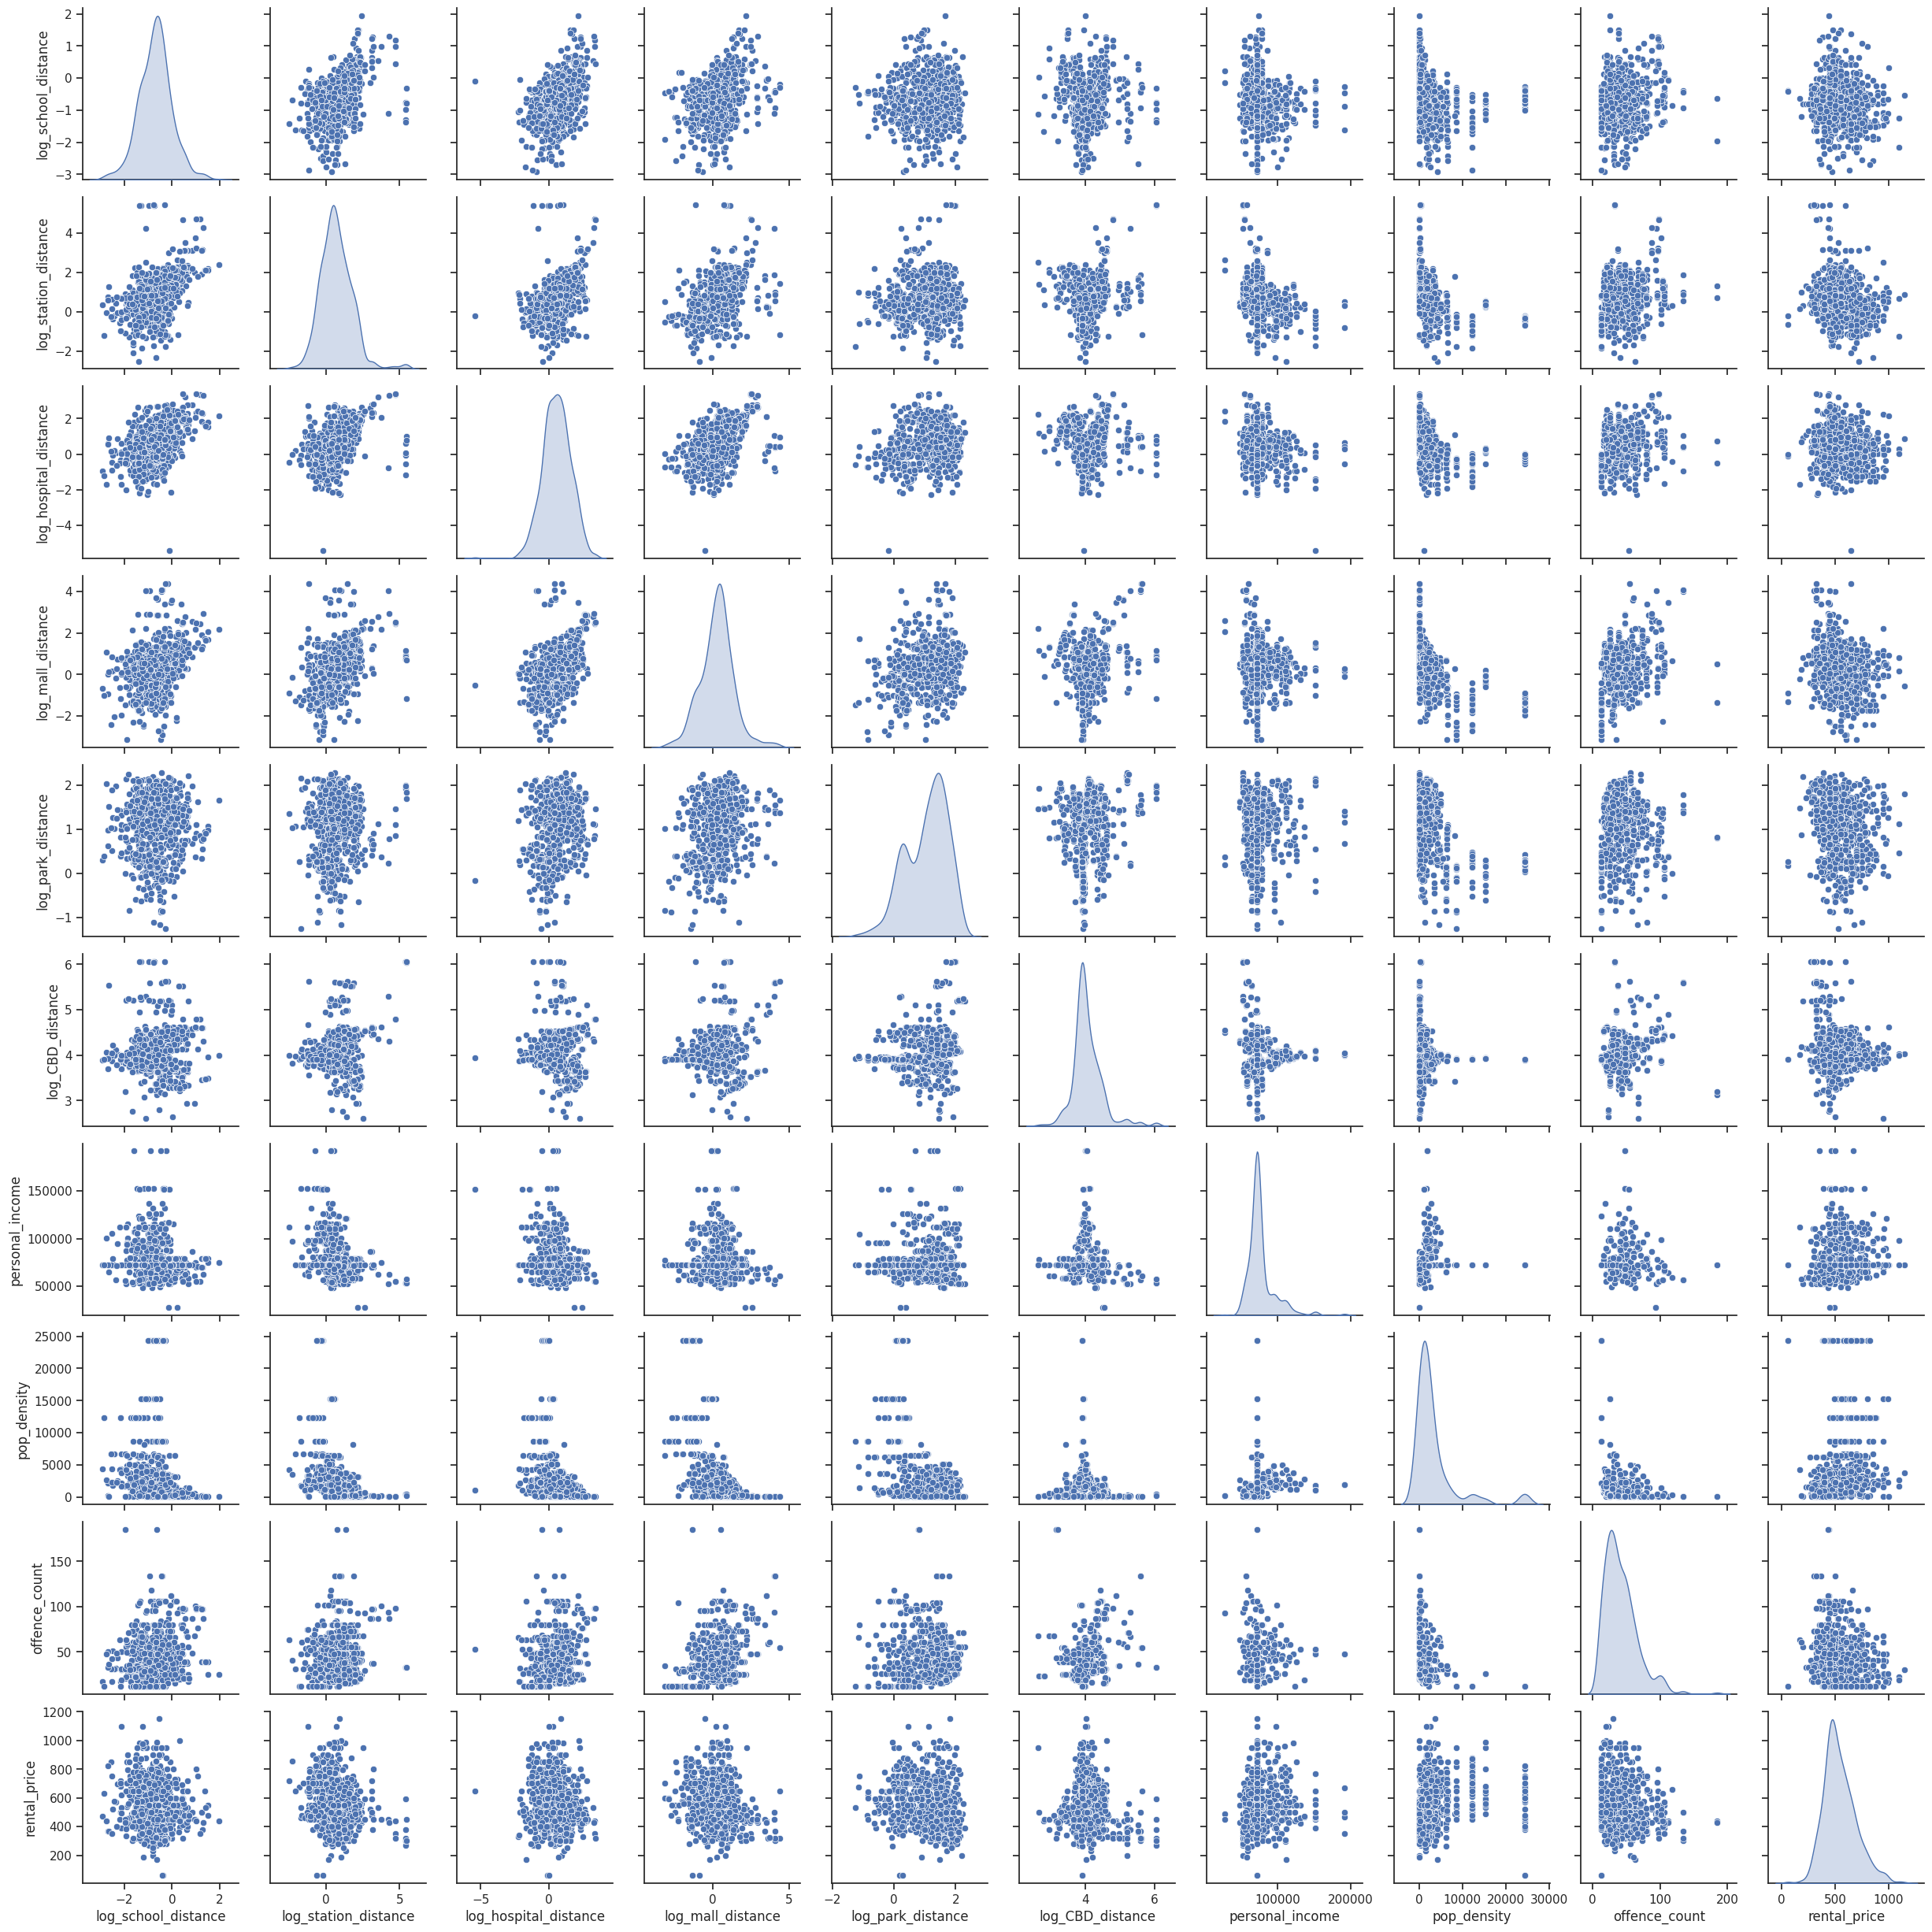

In [5]:
# Select the features for the pair plot
merged_data_sample = merged_data.sample(frac=0.1, random_state=1)
selected_features = distance_features + suburb_features + ['rental_price']
pair_plot_data = merged_data_sample[selected_features]

# Plot pair plot using Seaborn
sbs.set(style="ticks")
sbs.pairplot(pair_plot_data, diag_kind='kde')
fig_path = '../plots/pairplot'
plt.savefig(fig_path)
plt.show()

##### Finding: The relationshipp may not be linear, and the distribution may not be normal.

### 3. Draw the plots for analysing the correlations

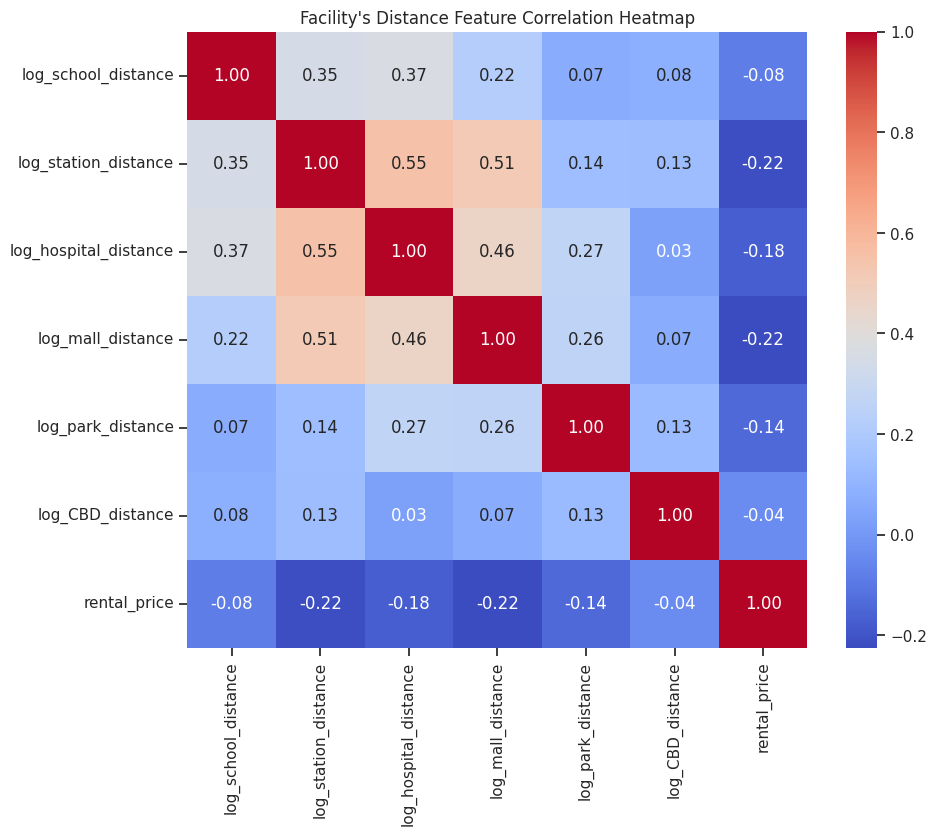

In [6]:
# claculate the correlation matrix by spearman: Facility's Distance Feature Correlation Heatmap
correlation_matrix = merged_data_distance.corr(method='spearman')
# use seaborn to draw heat map
plt.figure(figsize=(10, 8))
sbs.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Facility's Distance Feature Correlation Heatmap")
# save the plot
fig_path = '../plots/distance_&_price-heatmap'
plt.savefig(fig_path)
plt.show()

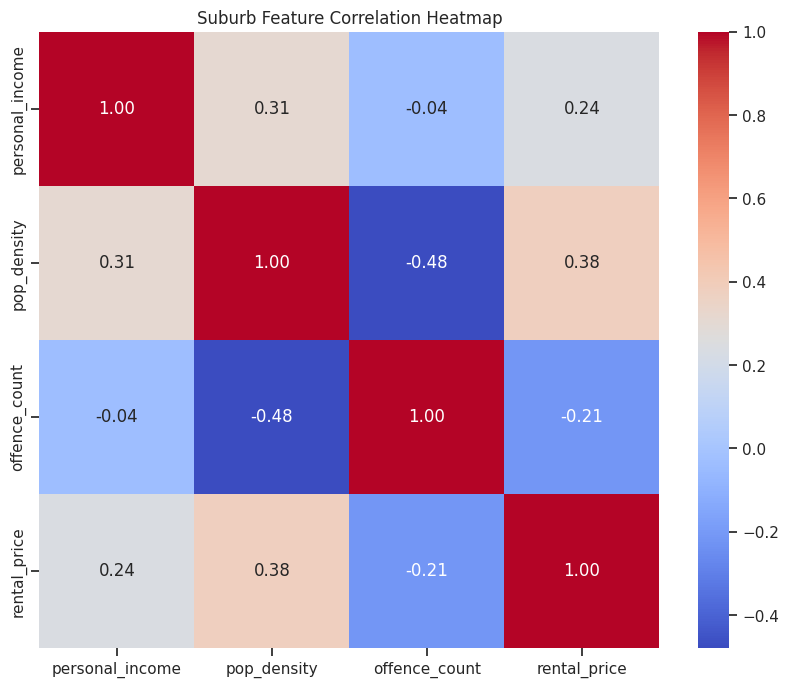

In [7]:
# claculate the correlation matrix by spearman: Facility's Distance Feature Correlation Heatmap
correlation_matrix = merged_data_suburb.corr(method='spearman')
# use seaborn to draw heat map
plt.figure(figsize=(10, 8))
sbs.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Suburb Feature Correlation Heatmap")
# save the plot
fig_path = '../plots/suburb_&_price-heatmap'
plt.savefig(fig_path)
plt.show()

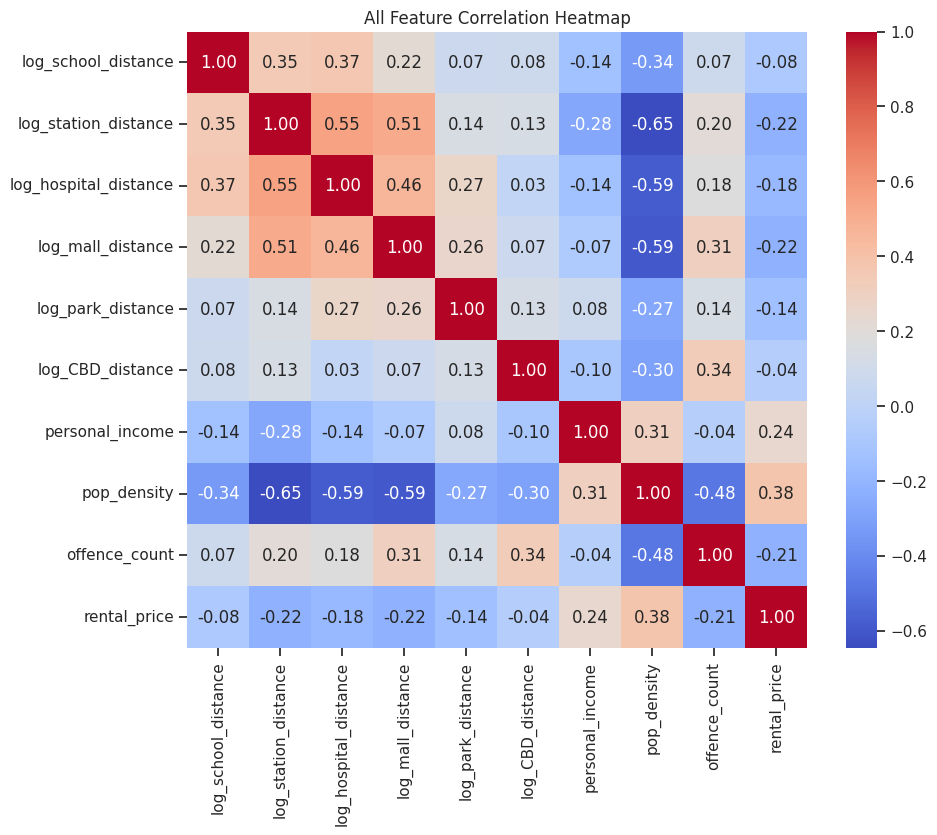

In [8]:
# claculate the correlation matrix by spearman: Facility's Distance Feature Correlation Heatmap
correlation_matrix = merged_data_all.corr(method='spearman')
# use seaborn to draw heat map
plt.figure(figsize=(10, 8))
sbs.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("All Feature Correlation Heatmap")
# save the plot
fig_path = '../plots/all_feature-heatmap'
plt.savefig(fig_path)
plt.show()